In [1]:
# Dataset url: https://www.kaggle.com/datasets/amitabhajoy/bengaluru-house-price-data

In [2]:
# Real Estate Price Prediction system of city Bengaluru from its dataset

# Data Loading and Data Cleaning

In [3]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# Load dataset and show the top five rows of the dataset
df1 = pd.read_csv('Bengaluru_House_Data.csv')
df1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [11]:
# Get the shape of the dataset (dataframe) in (row, column) format
df1.shape

(13320, 9)

In [12]:
# Is there any missing value present?
df1.isna().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [13]:
# How many different types of names inside the column 'area_type'
df1.groupby('area_type')['area_type'].agg('count')

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

In [14]:
# Here, in the dataframe df1, price is the target (dependent) variable, whereas all the other columns are independent (feature) variable
# Let's assume that some of the features are not that important to get the target
# Let's drop some of the columns
df2 = df1.drop(['area_type', 'availability', 'society', 'balcony'], axis=1)
df2.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [15]:
# Let's check whether there is null (missing) value present in df2
df2.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [16]:
# Here the highest number of missing value present is 73 which is inside 'bath' column, and the total rows of the dataframe is 13320
# This is just 0.54% of the total rows. (We can ignore/drop the values for less than 5% of missing values)
# So, either we can calculate the median of the columns and fill that median value in missing rows or we can drop the entire row with missing values
# Here, we are going to drop the rows with missing values
df3 = df2.dropna().copy()
df3.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [17]:
# Let's check shape of new dataframe df3
df3.shape

(13246, 5)

In [16]:
# Now Let's explore the columns

In [18]:
# Let's explore 'size' column
df3['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [19]:
# Creating new column 'bedroom', so that all the numeric value of 'size' gets into new column like '2' from '2 BHK' and '4' from '4 Bedroom'
df3['bedroom'] = df3['size'].apply(lambda x: int(x.split(' ')[0]))
df3.head()

,location,size,total_sqft,bath,price,bedroom
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [20]:
# Let's view all the unique value present in new column 'bedroom'
df3['bedroom'].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [21]:
# So, here we are seeing there are houses/apartment with 43 bedrooms as well. Let's have a quick look over it
# Let's display the house/apartment with more than 20 bedroom
df3[df3.bedroom > 20]

,location,size,total_sqft,bath,price,bedroom
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [22]:
# Let's have a look at unique values present in 'total_sqft' column
df3['total_sqft'].unique()    # OR, df3.total_sqft.unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      shape=(2067,), dtype=object)

In [28]:
# Here, we are seeing the values in range: '1133 - 1384' as well. Let's make this range value to a single number. For that, we can calculate average.
# So, let's check for the variation in 'total_sqft' feature. We can check for the values whether it is float or not

In [23]:
# Let's check for the values in 'total_sqft', whether it is float or not
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

In [24]:
# Check which of the values are not in float (values in range or other than float values)
df3[~df3['total_sqft'].apply(is_float)]

,location,size,total_sqft,bath,price,bedroom
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
...,...,...,...,...,...,...
12975,Whitefield,2 BHK,850 - 1060,2.0,38.190,2
12990,Talaghattapura,3 BHK,1804 - 2273,3.0,122.000,3
13059,Harlur,2 BHK,1200 - 1470,2.0,72.760,2
13265,Hoodi,2 BHK,1133 - 1384,2.0,59.135,2


In [25]:
# same as above, just we are viewing first 10 rows data
df3[~df3['total_sqft'].apply(is_float)].head(10)

,location,size,total_sqft,bath,price,bedroom
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,63.770,2
648,Arekere,9 Bedroom,4125Perch,9.0,265.000,9
661,Yelahanka,2 BHK,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,445.000,4


In [26]:
# Function to handle the values in range by calculating average of the range.
def convert_sqft_to_num(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0])+float(tokens[1]))/2
    try:
        return float(x)
    except:
        return None

In [38]:
# Test the above function

In [27]:
# As we are passing a single value, the function is converting the value into float, which is inside try block of the function
convert_sqft_to_num('2166')

2166.0

In [28]:
# When we passes the range value, it is returning the average value of the range, as in if block of the function
convert_sqft_to_num('2100 - 2850')

2475.0

In [29]:
# When we pass this type of value, it doesn't return anything, as mentioned in except block of the function
convert_sqft_to_num('34.46Sq. Meter')

In [30]:
df4 = df3.copy()   # making copy of the dataframe df3 and storing in df4

In [31]:
# Viewing first 5 rows
df4.head()

,location,size,total_sqft,bath,price,bedroom
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [32]:
# applying above function to 'total_sqft' column
df4['total_sqft'] = df4['total_sqft'].apply(convert_sqft_to_num)

In [33]:
# Viewing first 5 rows
df4.head()

,location,size,total_sqft,bath,price,bedroom
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


In [34]:
# From above df3 dataframe, we can see the index 30 has the range value
# Let's check if the function worked on total_sqft column, by directly locating the indexed value '30'
df4.loc[30]

location      Yelahanka
size              4 BHK
total_sqft       2475.0
bath                4.0
price             186.0
bedroom               4
Name: 30, dtype: object

In [35]:
df4.shape

(13246, 6)

In [36]:
# Let's check what happens to the values which were like this: '34.46Sq. Meter', by directly locating over there.
df4.loc[410]

location      Kengeri
size            1 BHK
total_sqft        NaN
bath              1.0
price            18.5
bedroom             1
Name: 410, dtype: object

In [37]:
# Checking for the null values in df4, after successsfully implementing average function to 'total_sqft' column
df4.isnull().sum()

location       0
size           0
total_sqft    46
bath           0
price          0
bedroom        0
dtype: int64

In [38]:
# Since there are 46 missing values present in 'total_sqft' column, we are removing the rows with missing values
df4 = df4.dropna()   # remove the rows with missing / null values
df4.isna().sum()   # display whether null value is present.

location      0
size          0
total_sqft    0
bath          0
price         0
bedroom       0
dtype: int64

# Feature Engineering and Dimensionality Reduction

In [39]:
# The dataset after data cleaning
df4.head()

,location,size,total_sqft,bath,price,bedroom
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


In [40]:
# Make a copy of dataframe df4
df5 = df4.copy()

In [62]:
# Now, we are going to create 'price_per_sqft' column, which is very important in real estate field. Also, this feature will help us cleaning outliers.

In [41]:
# Let's create 'price_per_sqft' column, which is the quotient of price (in lakh) and total_sqft
df5['price_per_sqft'] = df5['price']*100000/df5['total_sqft']

In [42]:
df5.head()

,location,size,total_sqft,bath,price,bedroom,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [43]:
# Let's dive into 'location' column. First let's view how many unique values are present in location column
len(df5.location.unique())

1298

In [44]:
# Let's first remove the extra spaces, that might present in the beginning or the end of the location's data
df5.location = df5['location'].apply(lambda x: x.strip())   # here df5.location and df5['location'] are same

In [45]:
# Let's view the data points that are available in location column
location_stats = df5.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_stats

location
Whitefield                         533
Sarjapur  Road                     392
Electronic City                    304
Kanakpura Road                     264
Thanisandra                        235
                                  ... 
beml layout, basaveshwara nagar      1
basaveshwarnagar                     1
1 Giri Nagar                         1
4 Bedroom Farm House in Bagalur      1
3rd Stage Raja Rajeshwari Nagar      1
Name: location, Length: 1287, dtype: int64

In [46]:
# Let's first view how many locations have less than 10 data points
len(location_stats[location_stats<=10])

1047

In [75]:
# So, there are 1047 location with less than 10 data points, so we can change the name of all of these to 'other'

In [47]:
# Viewing the locations having data points less than 10
location_stats_less_than_10 = location_stats[location_stats<=10]
location_stats_less_than_10

location
1st Block Koramangala              10
Thyagaraja Nagar                   10
Ganga Nagar                        10
Nagappa Reddy Layout               10
Gunjur Palya                       10
                                   ..
beml layout, basaveshwara nagar     1
basaveshwarnagar                    1
1 Giri Nagar                        1
4 Bedroom Farm House in Bagalur     1
3rd Stage Raja Rajeshwari Nagar     1
Name: location, Length: 1047, dtype: int64

In [48]:
# Display total unique locations
len(df5.location.unique())

1287

In [49]:
# Apply transformation: location having less than 10 data points are converted to 'other'
df5.location = df5.location.apply(lambda x: 'other' if x in location_stats_less_than_10 else x)
len(df5.location.unique())   # displays the length of unique values of location

241

In [50]:
df5.head(10)

,location,size,total_sqft,bath,price,bedroom,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
5,Whitefield,2 BHK,1170.0,2.0,38.00,2,3247.863248
6,Old Airport Road,4 BHK,2732.0,4.0,204.00,4,7467.057101
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.00,4,18181.818182
8,Marathahalli,3 BHK,1310.0,3.0,63.25,3,4828.244275
9,other,6 Bedroom,1020.0,6.0,370.00,6,36274.509804


# Outlier Detection and Removal

In [51]:
# Let's display the dataset with value that are lesser than some threshold / condition
df5[(df5.total_sqft/df5.bedroom)<300].head()

,location,size,total_sqft,bath,price,bedroom,price_per_sqft
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274.509804
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333.333333
58,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,10660.980810
68,Devarachikkanahalli,8 Bedroom,1350.0,7.0,85.0,8,6296.296296
70,other,3 Bedroom,500.0,3.0,100.0,3,20000.000000


In [52]:
df5.shape

(13200, 7)

In [53]:
# Remove all the outliers using the following condition
df6 = df5[~((df5.total_sqft/df5.bedroom)<300)]
df6.shape   # view the shape of the data

(12456, 7)

In [54]:
# let's look at basic statistics on price_per_sqft using describe()
df6.price_per_sqft.describe()

count     12456.000000
mean       6308.502826
std        4168.127339
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [55]:
# Function to remove extreme cases from price_per_sqft based on standard deviation, but per location
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

In [56]:
df7 = remove_pps_outliers(df6)
df7.shape

(10242, 7)

In [57]:
def plot_scatter_chart(df, location):
    bedroom2 = df[(df.location==location) & (df.bedroom==2)]
    bedroom3 = df[(df.location==location) & (df.bedroom==3)]
    plt.figure(figsize=(15,10))
    plt.scatter(bedroom2.total_sqft, bedroom2.price, marker='o', color='blue', label='2 BHK', s=50)
    plt.scatter(bedroom3.total_sqft, bedroom3.price, marker='x', color='green', label='3 BHK', s=50)
    plt.xlabel('Total Square Feet Area')
    plt.ylabel('Price Per Square Feet')
    plt.title(location)
    plt.legend()
    plt.show()

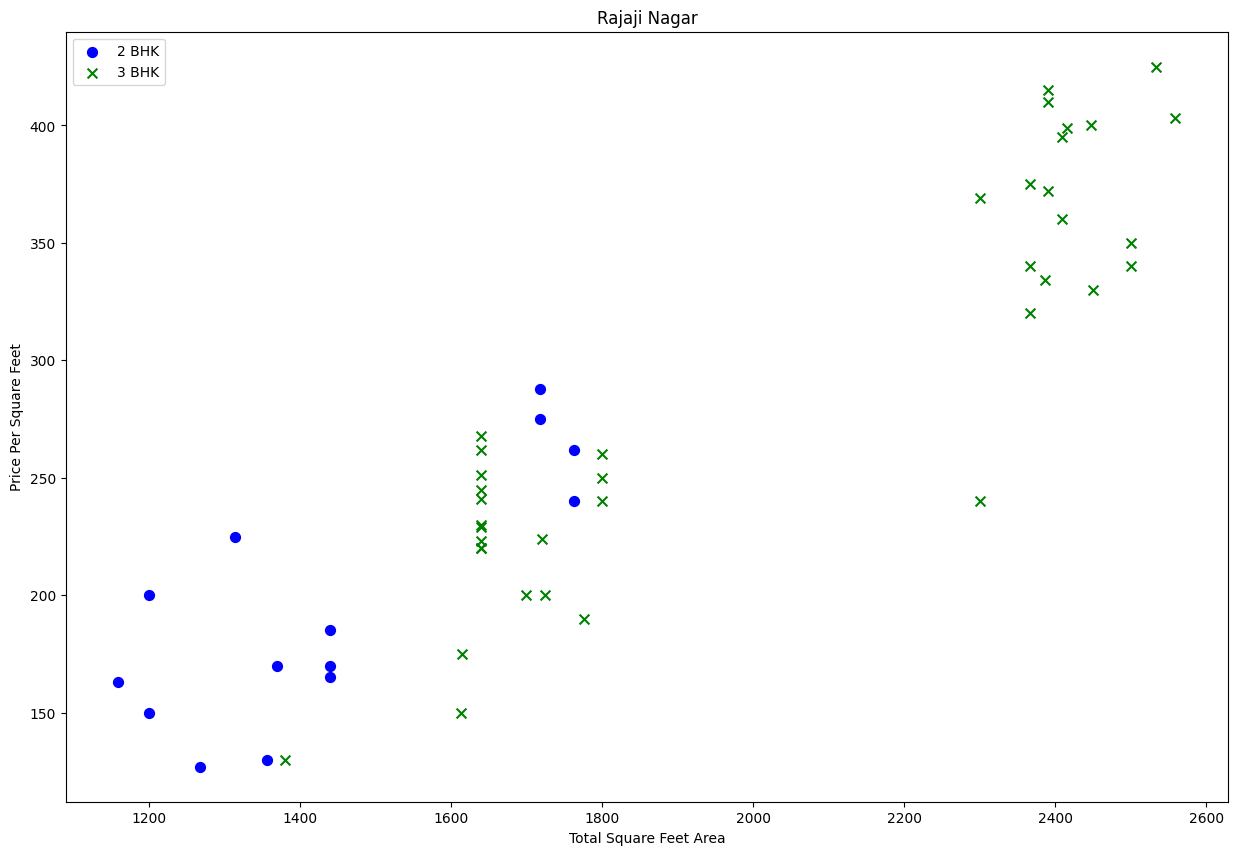

In [58]:
# Let's check for 'Rajaji Nagar'
plot_scatter_chart(df7, 'Rajaji Nagar')

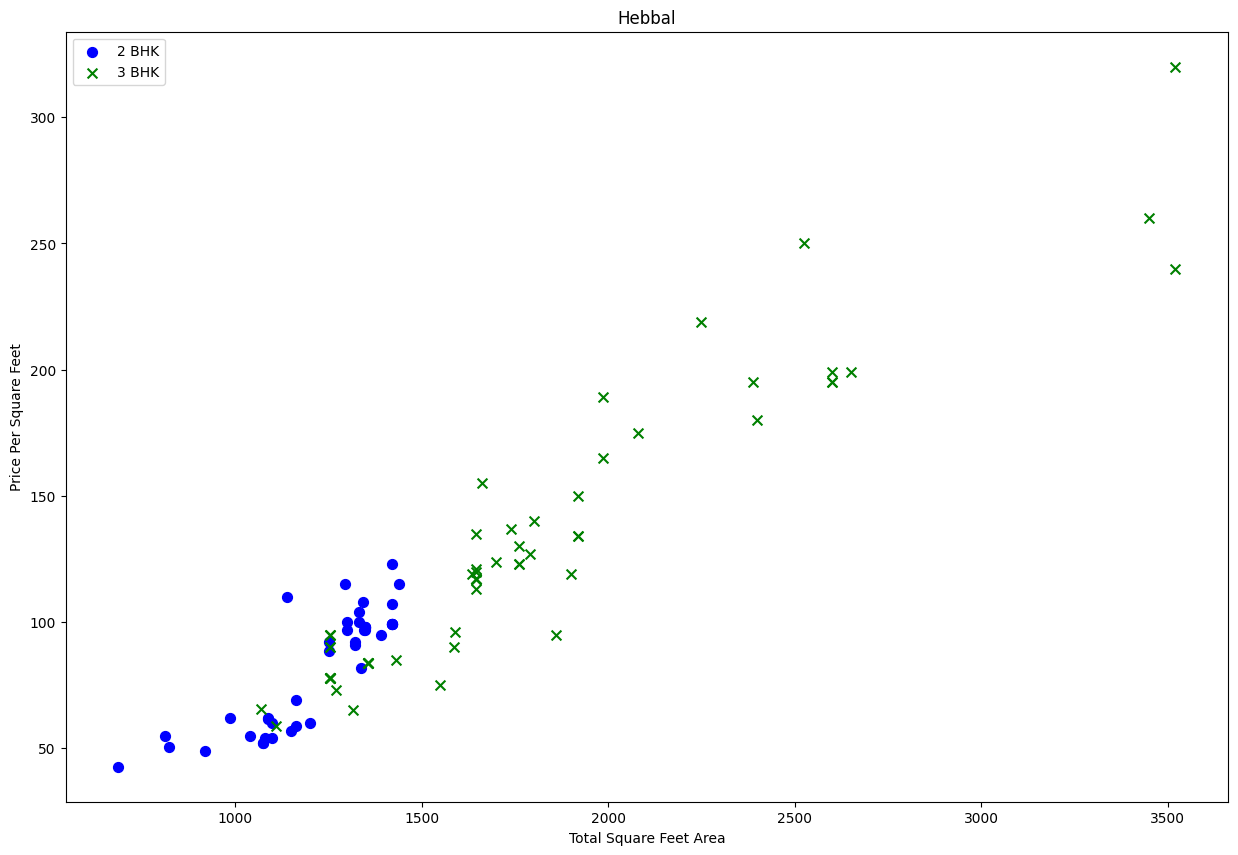

In [59]:
# Let's check for 'Hebbal'
plot_scatter_chart(df7, 'Hebbal')

In [60]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bedroom'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bedroom'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices, axis='index')

In [61]:
df8 = remove_bhk_outliers(df7)
df8.shape

(7317, 7)

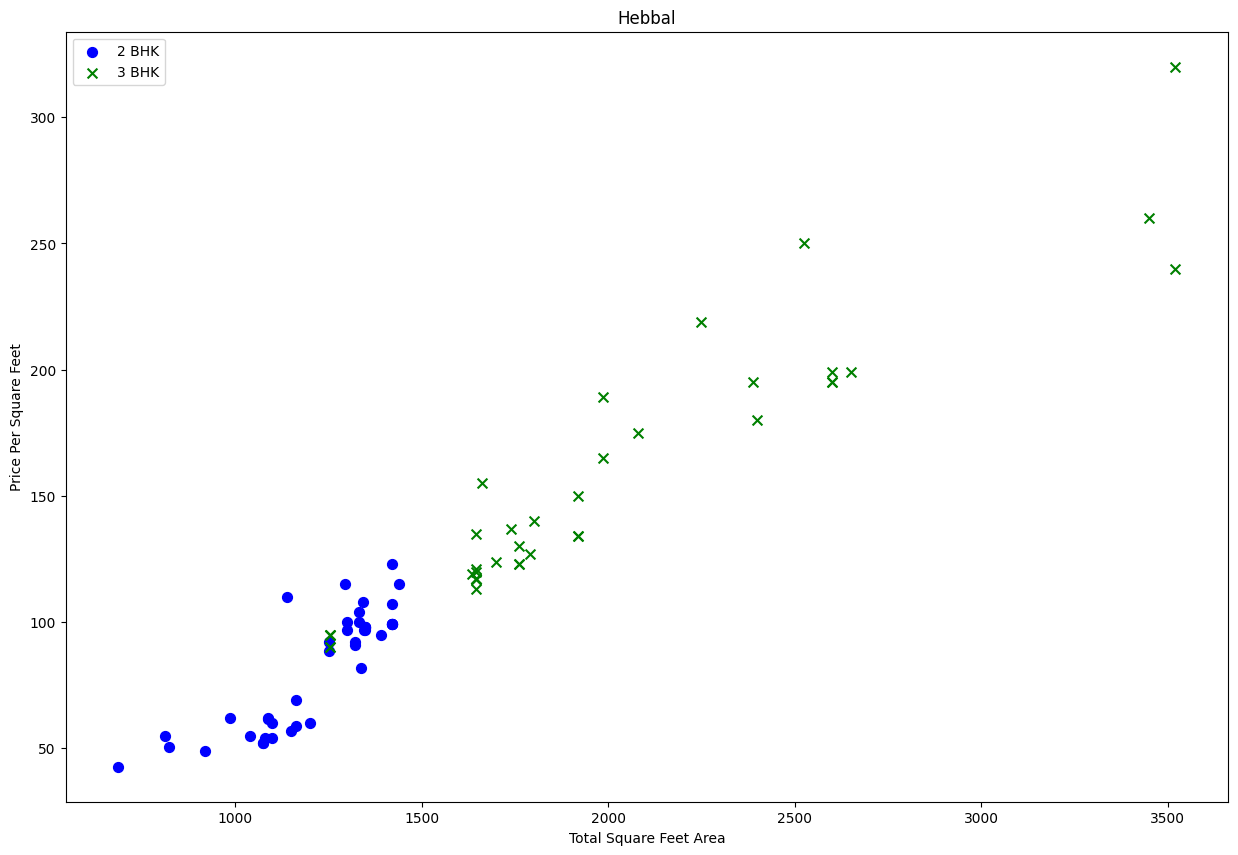

In [62]:
# Let's again plot the scatter plot, to see what changes the above function has made
plot_scatter_chart(df8, 'Hebbal')

In [101]:
# Here, from above figure, we can see a lot improvement in the dataset, as many outliers are removed.

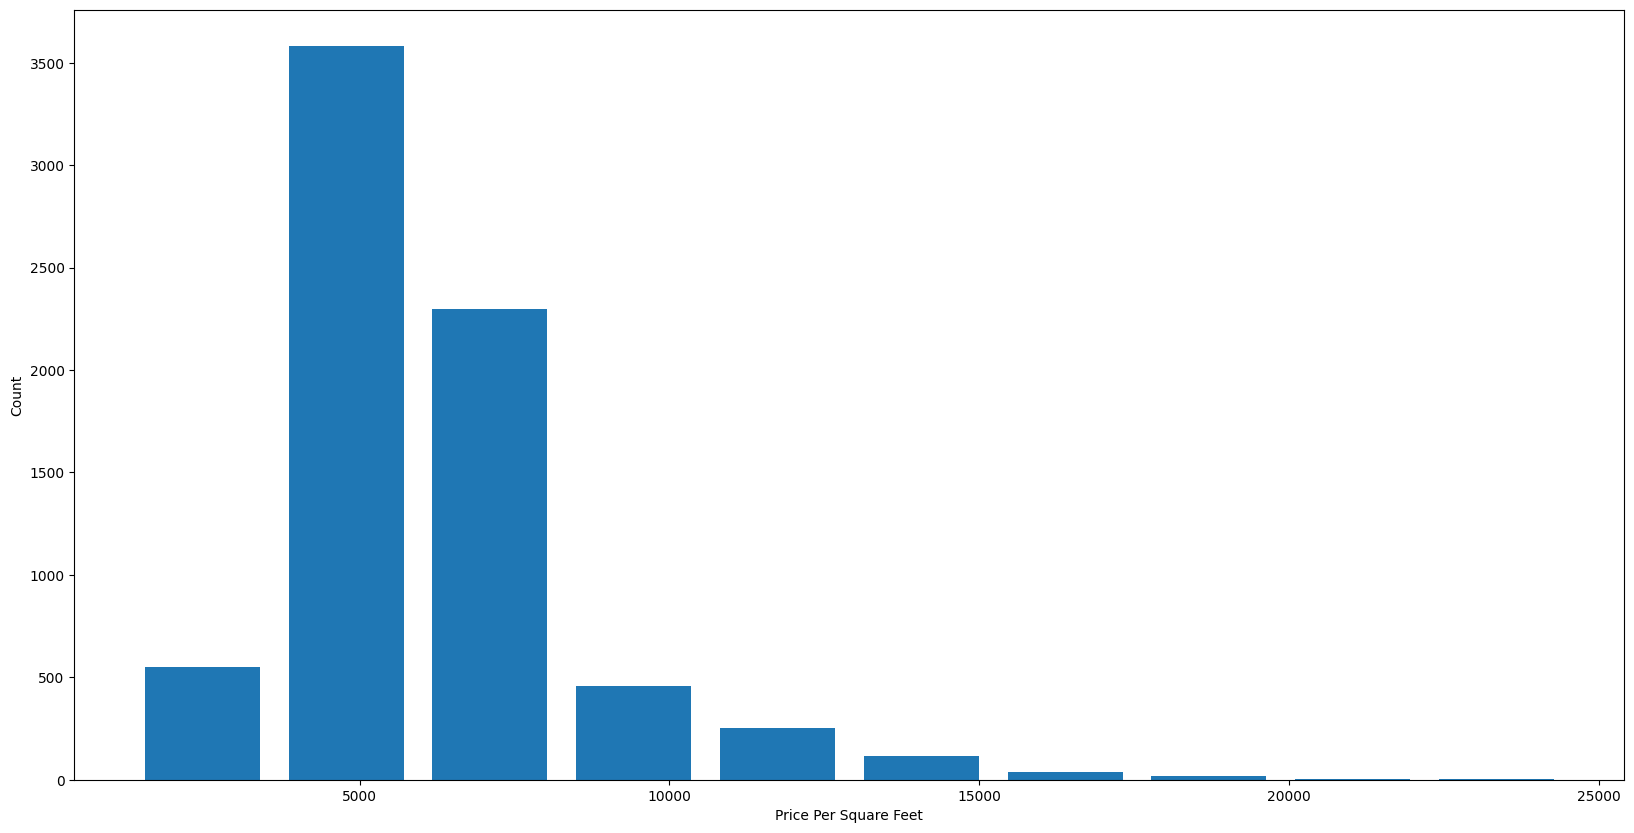

In [63]:
# Let's have a look over the property with price per sqft area
plt.figure(figsize=(20,10))
plt.hist(df8.price_per_sqft, rwidth=0.8)
plt.xlabel('Price Per Square Feet')
plt.ylabel('Count')
plt.show()

In [64]:
# Let's explore the bathroom feature
df8.bath.unique()

array([ 4.,  3.,  2.,  5.,  8.,  1.,  6.,  7.,  9., 12., 16., 13.])

In [65]:
# As we are seeing that there are bathrooms more than 10, so we are exploring what type of property are those.
df8[df8.bath>10]

,location,size,total_sqft,bath,price,bedroom,price_per_sqft
5277,Neeladri Nagar,10 BHK,4000.0,12.0,160.0,10,4000.000000
8483,other,10 BHK,12000.0,12.0,525.0,10,4375.000000
8572,other,16 BHK,10000.0,16.0,550.0,16,5500.000000
9306,other,11 BHK,6000.0,12.0,150.0,11,2500.000000
9637,other,13 BHK,5425.0,13.0,275.0,13,5069.124424


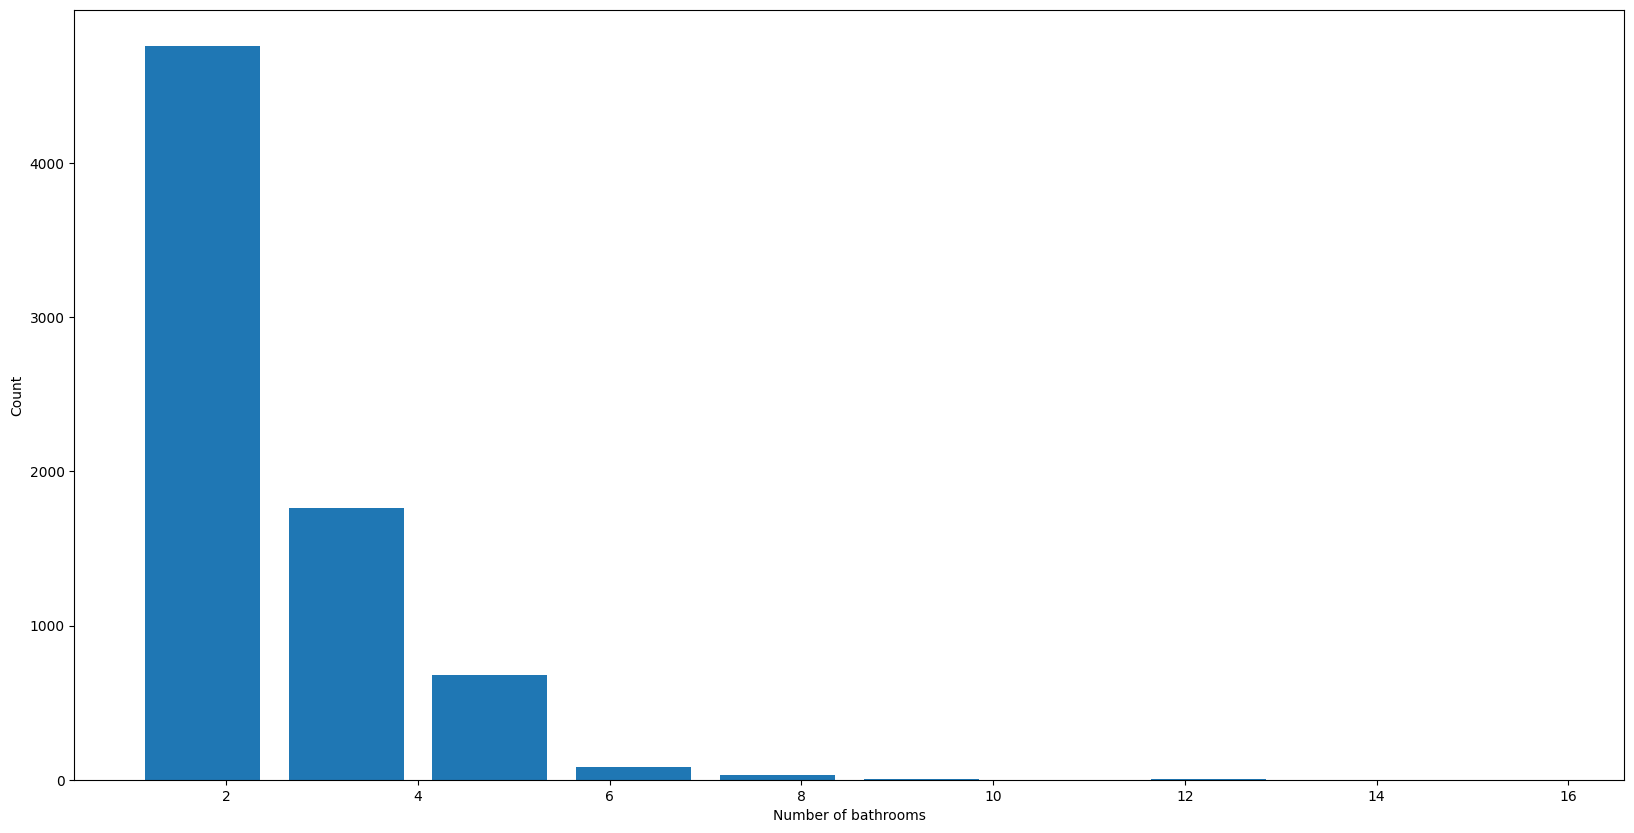

In [66]:
# Before doing anything, first let's have a look by ploting histogram
plt.figure(figsize=(20,10))
plt.hist(df8.bath, rwidth=0.8)
plt.xlabel('Number of bathrooms')
plt.ylabel('Count')
plt.show()

In [67]:
# Let's check how many outliers are present
df8[df8.bath>df8.bedroom+2]

,location,size,total_sqft,bath,price,bedroom,price_per_sqft
1626,Chikkabanavar,4 Bedroom,2460.0,7.0,80.0,4,3252.032520
5238,Nagasandra,4 Bedroom,7000.0,8.0,450.0,4,6428.571429
6711,Thanisandra,3 BHK,1806.0,6.0,116.0,3,6423.034330
8408,other,6 BHK,11338.0,9.0,1000.0,6,8819.897689


In [68]:
# Removing the outliers present from bathroom
df9 = df8[df8.bath<df8.bedroom+2]
df9.shape

(7239, 7)

In [69]:
# We can drop the unnecessary features from above dataframe. Here we can remove size, as we have bedroom(similar to size).
# And we can remove price_per_sqft, as that was the column (feature), we created for our convenience.
df10 = df9.drop(['size', 'price_per_sqft'], axis='columns')
df10.head()

,location,total_sqft,bath,price,bedroom
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2


# Model Building

In [70]:
df10['location'] = df10['location'].str.strip().str.lower()
df10.head()

,location,total_sqft,bath,price,bedroom
0,1st block jayanagar,2850.0,4.0,428.0,4
1,1st block jayanagar,1630.0,3.0,194.0,3
2,1st block jayanagar,1875.0,2.0,235.0,3
3,1st block jayanagar,1200.0,2.0,130.0,3
4,1st block jayanagar,1235.0,2.0,148.0,2


In [71]:
# Use one-hot encoding in location column
dummies = pd.get_dummies(df10.location)
dummies.head()

,1st block jayanagar,1st phase jp nagar,2nd phase judicial layout,2nd stage nagarbhavi,5th block hbr layout,5th phase jp nagar,6th phase jp nagar,7th phase jp nagar,8th phase jp nagar,9th phase jp nagar,...,vijayanagar,vishveshwarya layout,vishwapriya layout,vittasandra,whitefield,yelachenahalli,yelahanka,yelahanka new town,yelenahalli,yeshwanthpur
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [72]:
# Append dummies dataframe with our main dataframe, and to avoid a dummy variable trap, we need to drop one column from dummies
# Here, we are dropping the last column 'other'
df11 = pd.concat([df10, dummies.drop('other', axis='columns')], axis='columns')
df11.head()

,location,total_sqft,bath,price,bedroom,1st block jayanagar,1st phase jp nagar,2nd phase judicial layout,2nd stage nagarbhavi,5th block hbr layout,...,vijayanagar,vishveshwarya layout,vishwapriya layout,vittasandra,whitefield,yelachenahalli,yelahanka,yelahanka new town,yelenahalli,yeshwanthpur
0,1st block jayanagar,2850.0,4.0,428.0,4,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1st block jayanagar,1630.0,3.0,194.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1st block jayanagar,1875.0,2.0,235.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1st block jayanagar,1200.0,2.0,130.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1st block jayanagar,1235.0,2.0,148.0,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [73]:
# Since we have created dummy columns, we can now remove 'location' column
df12 = df11.drop('location', axis='columns')
df12.head()

,total_sqft,bath,price,bedroom,1st block jayanagar,1st phase jp nagar,2nd phase judicial layout,2nd stage nagarbhavi,5th block hbr layout,5th phase jp nagar,...,vijayanagar,vishveshwarya layout,vishwapriya layout,vittasandra,whitefield,yelachenahalli,yelahanka,yelahanka new town,yelenahalli,yeshwanthpur
0,2850.0,4.0,428.0,4,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,194.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,235.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,130.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,148.0,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [74]:
df12.shape

(7239, 244)

In [75]:
# Creating feature variable
X = df12.drop('price', axis='columns')
X.head()

,total_sqft,bath,bedroom,1st block jayanagar,1st phase jp nagar,2nd phase judicial layout,2nd stage nagarbhavi,5th block hbr layout,5th phase jp nagar,6th phase jp nagar,...,vijayanagar,vishveshwarya layout,vishwapriya layout,vittasandra,whitefield,yelachenahalli,yelahanka,yelahanka new town,yelenahalli,yeshwanthpur
0,2850.0,4.0,4,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [76]:
# Creating target variable
y = df12['price']
y.head()

0    428.0
1    194.0
2    235.0
3    130.0
4    148.0
Name: price, dtype: float64

In [77]:
# Spliting the dataset into train and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
# Train the model using Linear Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()   # Initialize the model
lr_model.fit(X_train, y_train)   # Train the model

lr_model.score(X_test, y_test)   # Evaluate the model

0.7971924202569046

In [79]:
# Using k-fold cross validation method
from sklearn.model_selection import ShuffleSplit, cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

cross_val_score(LinearRegression(), X, y, cv=cv)

array([0.79719242, 0.85349761, 0.86025581, 0.89009   , 0.81261021])

In [80]:
# Checking the model with different algorithms using GridSearchCV
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor

# Function to find the best model using GridSearchCV and using hyperparameter tuning to get the best result
def find_best_model_using_gridsearchcv(X, y):
    algos = {
        'linear_regression': {
            'model': LinearRegression(),
            'params': {
                'fit_intercept': [True, False]
            }
        },
        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [1, 2],
                'selection': ['random', 'cyclic']
            }
        },
        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion': ['squared_error', 'friedman_mse'],
                'splitter': ['best', 'random']
            }
        }
    }

    scores = []
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
    for algo_name, config in algos.items():
        gs = GridSearchCV(config['model'], config['params'], cv=cv, scoring='r2', return_train_score=False)
        gs.fit(X, y)
        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })

    return pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])


find_best_model_using_gridsearchcv(X, y)

,model,best_score,best_params
0,linear_regression,0.843343,{'fit_intercept': False}
1,lasso,0.698179,"{'alpha': 2, 'selection': 'cyclic'}"
2,decision_tree,0.694251,"{'criterion': 'squared_error', 'splitter': 'ra..."


In [81]:
# Initialize and train linear regression model using best parameters
lr_best_model = LinearRegression(fit_intercept=True)

lr_best_model.fit(X_train, y_train)

lr_best_model.score(X_test, y_test)

0.7971924202569046

In [155]:
# Making property price prediction for some samples to test
# Function to predict price
# def predict_price(location, sqft, bath, bedroom):
#     loc_index = np.where(X.columns==location)[0][0]

#     x = np.zeros(len(X.columns))
#     x[0] = sqft
#     x[1] = bath
#     x[2] = bedroom
#     if loc_index >= 0:
#         x[loc_index] = 1

#     return float(lr_best_model.predict([x])[0])

In [88]:
# Making property price prediction for some samples to test with
# Function to predict price
def predict_price(location, sqft, bath, bedroom):
    # Convert location to lowercase to match training
    location = location.strip().lower()
    
    # Create a zero-filled DataFrame with correct columns
    x = pd.DataFrame(
        np.zeros((1, len(X.columns))),
        columns=X.columns
    )

    # Assign values
    x['total_sqft'] = sqft
    x['bath'] = bath
    x['bedroom'] = bedroom

    # One-hot encode location if it exists
    if location in X.columns:
        x[location] = 1

    return float(lr_best_model.predict(x)[0])

In [89]:
predict_price('1st Phase JP Nagar', 1000, 2, 2)

97.21063159877224

In [90]:
predict_price('1st Phase JP Nagar', 1000, 3, 3)

101.59047425967906

In [91]:
predict_price('Indira Nagar', 1000, 2, 2)

192.90949707593046

In [92]:
predict_price('Indira Nagar', 1000, 3, 3)

197.2893397368373

In [93]:
predict_price('1st Phase JP Nagar', 1000, 2, 3)

96.29679051720063

In [94]:
# Exporting the model in pickle file
import pickle

with open('banglore_house_price_prediction_model.pickle', 'wb') as f:
    pickle.dump(lr_best_model, f)

In [95]:
# Exporting all the columns into json file
import json

columns = {
    'data_columns': [col.lower() for col in X.columns]
}

with open('columns.json', 'w') as f:
    f.write(json.dumps(columns))